<a href="https://colab.research.google.com/github/o-nastasia/CS50-s-Intro-to-AI-with-Python/blob/main/Signal_types_classification_(Kaggle).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
from google.colab import userdata
from collections import Counter
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import userdata
from IPython.display import Image, display
from pandas.plotting import scatter_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    silhouette_score,
    silhouette_samples,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from yellowbrick.cluster import SilhouetteVisualizer

In [2]:
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

In [3]:
!gdown '1q_HFKpqvim_WnPo49iQM5Qa7x7GJgTUm'

Downloading...
From: https://drive.google.com/uc?id=1q_HFKpqvim_WnPo49iQM5Qa7x7GJgTUm
To: /content/res.png
100% 76.9k/76.9k [00:00<00:00, 50.7MB/s]


# Загрузка данных

In [4]:
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
path = kagglehub.competition_download('signal-types-classification')
file_path = f"{path}/Run200_Wave_0_1.txt"
data = pd.read_csv(file_path, sep=' ', header=None, skipinitialspace=True)

In [5]:
data.head(2)

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB


In [7]:
data.describe()

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
count,2.347900e+04,23479.000000,23479.000000,23479.0,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,0.0
mean,1.009742e+11,869.160015,372.191661,500.0,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,...,14822.315686,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743,NaN
std,5.715472e+10,572.905756,470.391688,0.0,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,...,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307,NaN
min,2.890276e+06,0.000000,10.000000,500.0,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,...,14798.000000,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000,NaN
25%,5.156311e+10,373.000000,64.000000,500.0,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,NaN
50%,1.014553e+11,810.000000,172.000000,500.0,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,NaN
75%,1.502418e+11,1341.000000,483.000000,500.0,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,NaN
max,2.000107e+11,1998.000000,3370.000000,500.0,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,...,14835.000000,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000,NaN


Исходный датасет содержит данные о 23 479 сигналов по 505 отсчетам каждый. Все амплитудные каналы представлены в целочисленном формате АЦП, кроме одного. Базовая линия стабильна и находится в районе 14 820 - 14 825 бит АЦП с шумом около 3 бит. Столбец 504 пуст (NaN) и должен быть удален перед расчетами.

# EDA

## Предобработка

Исключим из исходного набора неинформативные технические признаки с индексами 0, 1, 2, 3 и 504, которые не содержат полезной информации для классификации сигналов, и выполним переиндексацию оставшихся 500 признаков, присвоив им новые числовые имена от 0 до 499.

In [8]:
data = data.drop([0, 1, 2, 3, 504], axis=1)
data.columns = list(range(500))

Вычислим среднее значение по первым 50 отсчетам для определения индивидуального уровня фона каждого сигнала и вычтем его, чтобы устранить смещение базовой линии и привести сигналы к единому нулю. Затем сменим полярность данных на противоположную, чтобы преобразовать отрицательные импульсы АЦП в положительные пики, что необходимо для корректного расчета математической площади под графиком при разделении частиц.

In [9]:
baseline = data.iloc[:, 0:50].mean(axis=1)
data_clean = data.sub(baseline, axis=0)
matrix = -data_clean.values

## Визуализация исходных данных

Построим графики первых 100 сигналов на временном интервале от 140 до 200 нс в осях времени и амплитуды АЦП, чтобы наглядно отобразить и сравнить форму их импульсов.

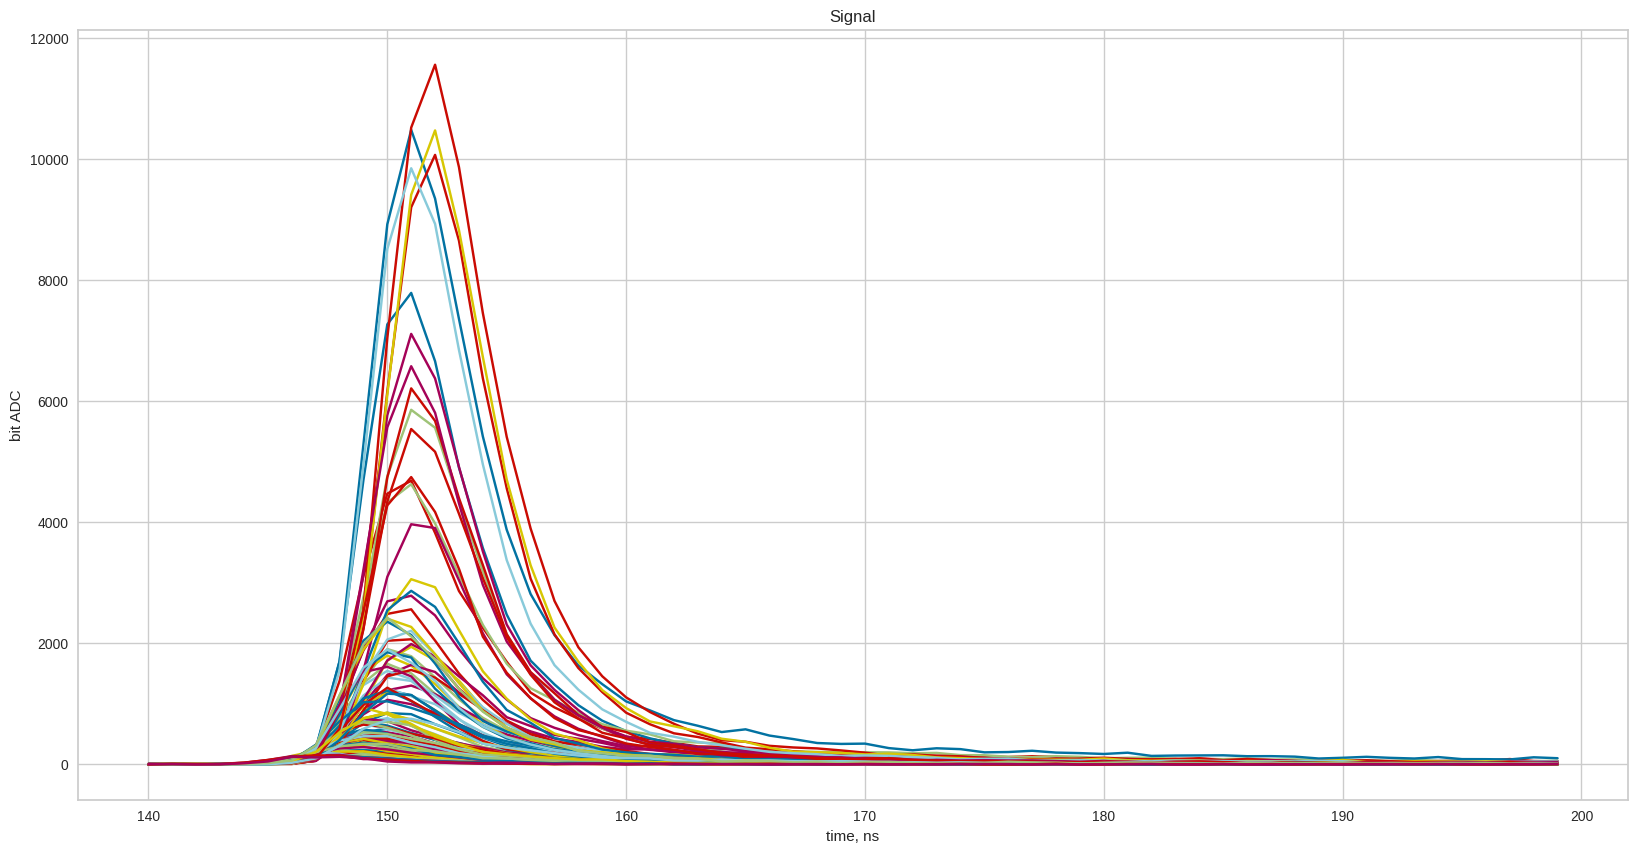

In [10]:
time_axis = range(140, 200)
plt.figure(figsize=(20, 10))
plt.plot(time_axis, matrix[0:100, 140:200].T)
plt.title('Signal')
plt.xlabel("time, ns")
plt.ylabel("bit ADC")
plt.show()

Визуализация выборки сырых сигналов показывает, что импульсы имеют классическую для сцинтилляционных детекторов форму: они стартуют с общего базового фонового уровня, демонстрируют быстрый фронт нарастания (пик вверх с максимальной амплитудой до 12 000 бит АЦП) и последующий плавный спад к исходному фону в течение примерно 40 нс.

Четко прослеживаются два основных типа поведения - сигналы с коротким хвостом (вероятно, гамма-кванты) и с заметно более протяженным хвостом (нейтроны за счет отдачи протонов). Также видна группа событий с очень низкой амплитудой и искажённой формой - это кандидат в третий кластер (шум и артефакты).

Наличие такой вариативности в геометрии треков подтверждает сложную физическую структуру данных и указывает на необходимость извлечения детальных временных признаков для последующего разделения сигналов.

## Анализ распределения сигналов

Построим диаграмму рассеяния между максимальной амплитудой и полной площадью сигнала, чтобы оценить структуру данных до создания сложных признаков.

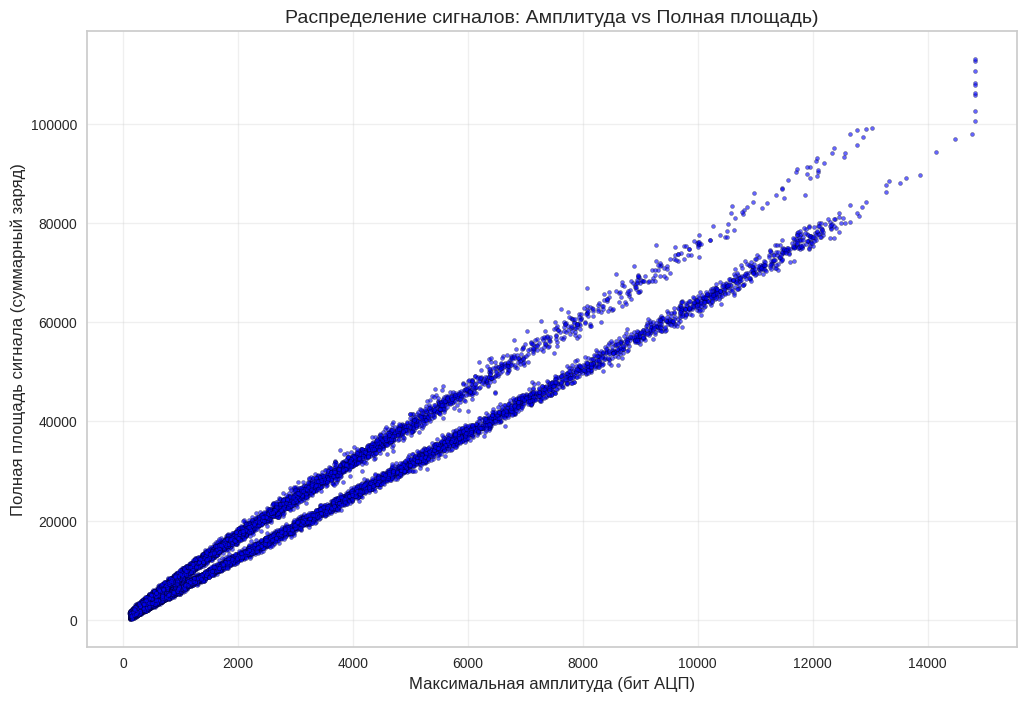

In [11]:
amplitudes_eda = np.max(matrix, axis=1)
total_area_eda = np.sum(matrix, axis=1)

plt.figure(figsize=(12, 8))
plt.scatter(amplitudes_eda, total_area_eda,
            s=8, alpha=0.6, c='blue', edgecolors='black', linewidth=0.3)
plt.xlabel('Максимальная амплитуда (бит АЦП)', fontsize=12)
plt.ylabel('Полная площадь сигнала (суммарный заряд)', fontsize=12)
plt.title('Распределение сигналов: Амплитуда vs Полная площадь)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Диаграмма рассеяния амплитуды и полной площади сигнала показывает характерную веерообразную структуру с двумя основными ветвями. Нижняя ветвь более компактна, верхняя имеет больший разброс площади при той же амплитуде.
Это указывает, что сигналы с близкой энергией обладают разной длительностью хвоста: быстрый спад типичен для гамма-квантов, более медленный - для нейтронов.
Полученная картина подтверждает низкую разделяющую способность амплитуды и полного заряда и обосновывает переход к параметрам формы импульса (PSD, доли хвоста и время высвечивания).

## Feature engineering

Нормализуем сигнал и найдем пики.

In [12]:
matrix_norm = matrix / np.max(matrix, axis=1, keepdims=True)
peak_indices = np.argmax(matrix, axis=1)

Чтобы выделить информативные признаки формы импульса (короткое окно, среднее окно, быстрый хвост, глубокий хвост), рассчитаем разность средних профилей сигналов с длинными и короткими хвостами. График покажет три точки для подбора окон: начало расхождения форм (p_start), максимум контраста (p_max) и слияние хвостов перед уходом в шум (p_end).

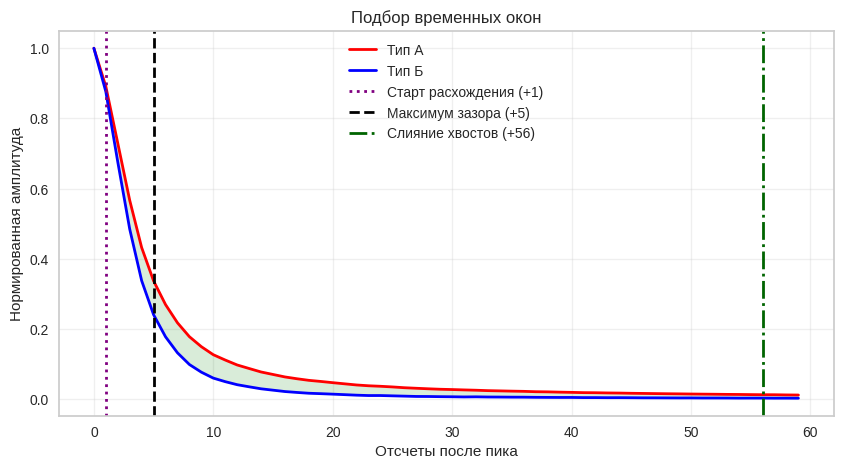

In [13]:
max_look_ahead = 60
aligned_signals = []

for i in range(len(matrix)):
    peak = peak_indices[i]
    tail = matrix[i][peak:peak + max_look_ahead]
    if len(tail) < max_look_ahead:
        tail = np.pad(tail, (0, max_look_ahead - len(tail)), 'edge')
    if matrix[i][peak] > 0:
        aligned_signals.append(tail / matrix[i][peak])
aligned_signals = np.array(aligned_signals)

tail_sums = aligned_signals[:, 5:].sum(axis=1)
threshold = np.median(tail_sums)

group_1 = aligned_signals[tail_sums >= threshold]
group_2 = aligned_signals[tail_sums < threshold]

mean_shape_1 = np.mean(group_1, axis=0)
mean_shape_2 = np.mean(group_2, axis=0)

diff = np.abs(mean_shape_1 - mean_shape_2)
p_max = np.argmax(diff)
p_start = np.where(diff > 0.05 * diff[p_max])[0][0]
p_end = np.where((diff < 0.1 * diff[p_max]) & (range(max_look_ahead) > p_max))[0][0]

plt.figure(figsize=(10, 5))
plt.plot(mean_shape_1, color='red', linewidth=2, label='Тип А')
plt.plot(mean_shape_2, color='blue', linewidth=2, label='Тип Б')
plt.fill_between(range(max_look_ahead), mean_shape_2, mean_shape_1, color='green', alpha=0.15)

plt.axvline(p_start, color='purple', linestyle=':', linewidth=2, label=f'Старт расхождения (+{p_start})')
plt.axvline(p_max, color='black', linestyle='--', linewidth=2, label=f'Максимум зазора (+{p_max})')
plt.axvline(p_end, color='darkgreen', linestyle='-.', linewidth=2, label=f'Слияние хвостов (+{p_end})')

plt.title('Подбор временных окон')
plt.xlabel('Отсчеты после пика')
plt.ylabel('Нормированная амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Расчет выдал точки p_start = 1, p_max = 5 и p_end = 56. На основе этих маркеров мы можем распределить границы окон. Короткое окно стоит взять в диапазоне 0 - 1, чтобы собрать заряд пика до начала расхождения форм. Среднее окно 4 - 12 и быстрый хвост 10 - 20 нужно настроить вокруг максимума 5, где разница между сигналами наибольшая. Глубокий хвост имеет смысл ограничить отметкой 50, так как после точки слияния 56 индивидуальные различия исчезают и начинается фоновый шум.

Инициализируем массивы для будущих признаков.

In [14]:
amplitudes = np.zeros(len(matrix))
area_long = np.zeros(len(data))
area_short = np.zeros(len(data))
rise_time = np.zeros(len(matrix))

fall_time_50 = np.zeros(len(matrix))
fall_time_10 = np.zeros(len(matrix))
area_mid = np.zeros(len(data))
area_tail = np.zeros(len(data))
area_tail_fast = np.zeros(len(data))
area_tail_deep = np.zeros(len(data))

Рассчитаем характеристики импульса. Проведем поточечный анализ формы каждого импульса в цикле. Определим геометрию сигнала: время нарастания, спада до уровней 50% и 10%, а также расчет площадей (интегралов) для разных участков трека.

In [15]:
short_window_size = 1

for i in range(len(matrix)):
    peak = peak_indices[i]
    signal = matrix[i]
    signal_norm = matrix_norm[i]
    amp = signal[peak]
    end_tail = min(peak + 40, 499)

    area_long[i] = signal[peak:].sum()
    end_short = min(peak + short_window_size, 499)
    area_short[i] = signal[peak:end_short + 1].sum()
    amplitudes[i] = signal[peak]
    area_tail[i] = signal[peak + 15 : end_tail + 1].sum()

    start_pulse = peak
    while start_pulse > 0 and signal[start_pulse] > (amp * 0.05):
        start_pulse -= 1
    rise_time[i] = max(peak - start_pulse, 1)
    t_50 = peak
    while t_50 < 499 and signal[t_50] > (amp * 0.5):
        t_50 += 1
    fall_time_50[i] = t_50 - peak

    t_10 = peak
    while t_10 < 499 and signal[t_10] > (amp * 0.1):
        t_10 += 1
    fall_time_10[i] = t_10 - peak
    end_mid = min(peak + 12, 499)
    area_mid[i] = signal[peak + 4 : end_mid + 1].sum()

    end_tail_fast = min(peak + 20, 499)
    area_tail_fast[i] = signal[peak + 10 : end_tail_fast + 1].sum()

    end_tail_deep = min(peak + 50, 499)
    area_tail_deep[i] = signal[peak + 25 : end_tail_deep + 1].sum()

Соберем датафрейм и рассчитаем относительные признаки: ключевые относительные коэффициенты формы (доли хвостов в полном заряде) и параметр разделения формы импульсов (PSD).

In [16]:
features = pd.DataFrame(index=data.index)
features['amplitude'] = amplitudes
features['area_long'] = area_long
features['area_short'] = area_short
features['rise_time'] = rise_time

features['fall_time_50'] = fall_time_50
features['fall_time_10'] = fall_time_10
features['area_tail'] = area_tail
features['ratio_tail_long'] = np.where(features['area_long'] != 0, features['area_tail'] / features['area_long'], 0.0)

features['ratio_tail_fast'] = np.where(features['area_long'] != 0, area_tail_fast / features['area_long'], 0.0)
features['ratio_tail_deep'] = np.where(features['area_long'] != 0, area_tail_deep / features['area_long'], 0.0)

features['psd'] = np.where(
    features['area_long'] != 0,
    (features['area_long'] - features['area_short']) / features['area_long'],
    0.0
)

features.head()

,amplitude,area_long,area_short,rise_time,fall_time_50,fall_time_10,area_tail,ratio_tail_long,ratio_tail_fast,ratio_tail_deep,psd
0,530.48,3938.48,973.96,4.0,4.0,11.0,468.48,0.118949,0.090461,0.096098,0.752707
1,1901.48,10122.00,3684.96,4.0,4.0,9.0,509.48,0.050334,0.061083,0.030575,0.635945
2,2557.90,11317.10,4599.80,5.0,3.0,8.0,538.40,0.047574,0.075187,0.028576,0.593553
3,564.56,3923.56,1090.12,4.0,4.0,10.0,499.56,0.127323,0.097401,0.067174,0.722160
4,1793.60,9105.00,3421.20,4.0,4.0,9.0,508.60,0.055859,0.069039,0.024448,0.624250


# Выбор и обучение модели кластеризации

## Масштабирование признаков и формирование итоговой матрицы для обучения моделей

Масштабируем признаки и сформируем итоговую матрицу для обучения моделей: геометрические параметры импульсов приведем к диапазону от 0 до 1 с помощью MinMaxScaler, а параметр разделения формы psd стандартизируем через StandardScaler. После этого преобразуем данные и объединим их в единый признаковый массив X.

In [17]:
scaler_minmax = MinMaxScaler()
amp_area_scaled = scaler_minmax.fit_transform(features[[
    'amplitude', 'area_long', 'rise_time',
    'fall_time_50',
    'fall_time_10',
    'area_tail',
    'ratio_tail_long',
    'ratio_tail_fast',
    'ratio_tail_deep'
]])

scaler_standard = StandardScaler()
psd_scaled = scaler_standard.fit_transform(features[['psd']])

X = np.hstack([psd_scaled, amp_area_scaled])

## Обучение модели K-Means

### Подбор гиперпараметров

Подберем оптимальную комбинацию гиперпараметров, обеспечивающую наилучшее качество кластеризации без избыточных вычислительных затрат.

In [18]:
n_init_options = [5, 10, 15, 20]
max_iter_options = [100, 300, 500]

best_inertia = float('inf')
best_params = {}

for n_init in n_init_options:
    for max_iter in max_iter_options:
        start_time = time.time()

        kmeans_test = KMeans(n_clusters=3, n_init=n_init, max_iter=max_iter, random_state=42)
        kmeans_test.fit(X)

        elapsed_time = time.time() - start_time
        current_inertia = kmeans_test.inertia_

        print(f"n_init: {n_init:<2} | max_iter: {max_iter:<3} | Inertia: {current_inertia:.2f} | Time: {elapsed_time:.3f}s")

        if current_inertia < best_inertia:
            best_inertia = current_inertia
            best_params = {'n_init': n_init, 'max_iter': max_iter}

print(f"\nОптимальные параметры по критерию минимальной инерции: {best_params}")

n_init: 5  | max_iter: 100 | Inertia: 8318.62 | Time: 0.192s
n_init: 5  | max_iter: 300 | Inertia: 8318.62 | Time: 0.154s
n_init: 5  | max_iter: 500 | Inertia: 8318.62 | Time: 0.156s
n_init: 10 | max_iter: 100 | Inertia: 8318.62 | Time: 0.261s
n_init: 10 | max_iter: 300 | Inertia: 8318.62 | Time: 0.255s
n_init: 10 | max_iter: 500 | Inertia: 8318.62 | Time: 0.249s
n_init: 15 | max_iter: 100 | Inertia: 8318.62 | Time: 0.359s
n_init: 15 | max_iter: 300 | Inertia: 8318.62 | Time: 0.389s
n_init: 15 | max_iter: 500 | Inertia: 8318.62 | Time: 0.351s
n_init: 20 | max_iter: 100 | Inertia: 8318.62 | Time: 0.499s
n_init: 20 | max_iter: 300 | Inertia: 8318.62 | Time: 0.468s
n_init: 20 | max_iter: 500 | Inertia: 8318.62 | Time: 0.476s

Оптимальные параметры по критерию минимальной инерции: {'n_init': 10, 'max_iter': 100}


### Обучение

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=100)
raw_labels = kmeans.fit_predict(X)

print("Модель успешно обучена. Распределение кластеров:")
print(pd.Series(raw_labels).value_counts())

Модель успешно обучена. Распределение кластеров:
0    12581
1    10897
2        1
Name: count, dtype: int64


### Оценка качества кластеризации

#### Метод силуэтов и индекс Калински-Харабаша

Рассчитаем метрики внутренней валидации кластеризации - индекс Калински-Харабаша и коэффициент силуэта, чтобы количественно оценить плотность и разделимость полученных групп сигналов. Также построим график силуэта с помощью SilhouetteVisualizer.

Calinski-Harabasz: 25461.18 | Silhouette: 0.607


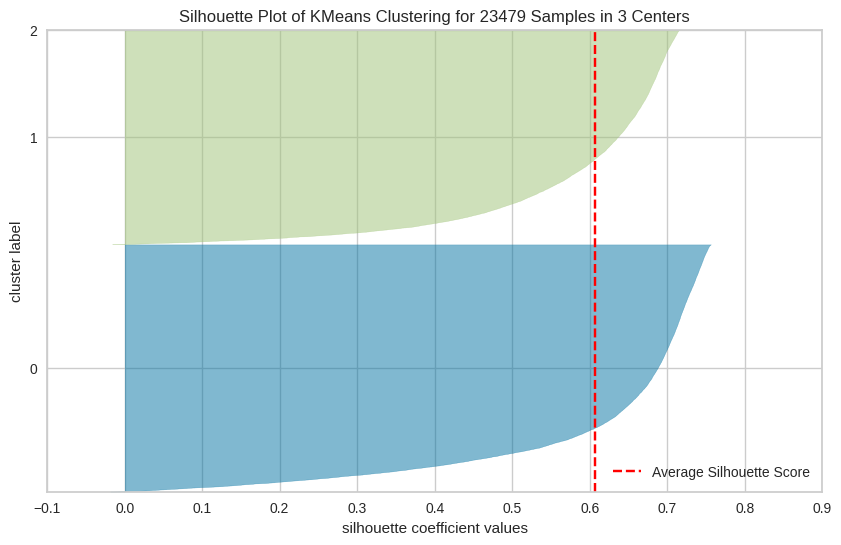

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23479 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [20]:
ch_kmeans = calinski_harabasz_score(X, raw_labels)
sil_kmeans = silhouette_score(X, raw_labels)
print(f"Calinski-Harabasz: {ch_kmeans:.2f} | Silhouette: {sil_kmeans:.3f}")

model = KMeans(n_clusters=3, random_state=42, n_init=10)
plt.figure(figsize=(10, 6))
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(X)
visualizer.show()

Коэффициент силуэта, равный 0.607, указывает на устойчивую структуру разбиения и хорошее разделение объектов между собой, а высокое значение индекса Калински-Харабаша (25461.18) подтверждает высокую плотность сформированных кластеров и существенное удаление их центроидов друг от друга.

Визуально на графике силуэтных профилей зафиксируем два равномерных, четко очерченных кластера ("тупых ножа"), что подтвердит качественное и устойчивое разделение основной массы сигналов на две группы. При этом отметим, что третий сформированный кластер практически не отобразится на графике ввиду экстремально малой мощности, так как он состоит всего из одной точки.

#### График рассеяния

Чтобы наглядно оценить геометрическое разделение сформированных групп сигналов на плоскости основных физических параметров, построим двухмерный график рассеяния в осях полной площади импульса (area_long) и его амплитуды (amplitude), отобразив метки кластеров цветом

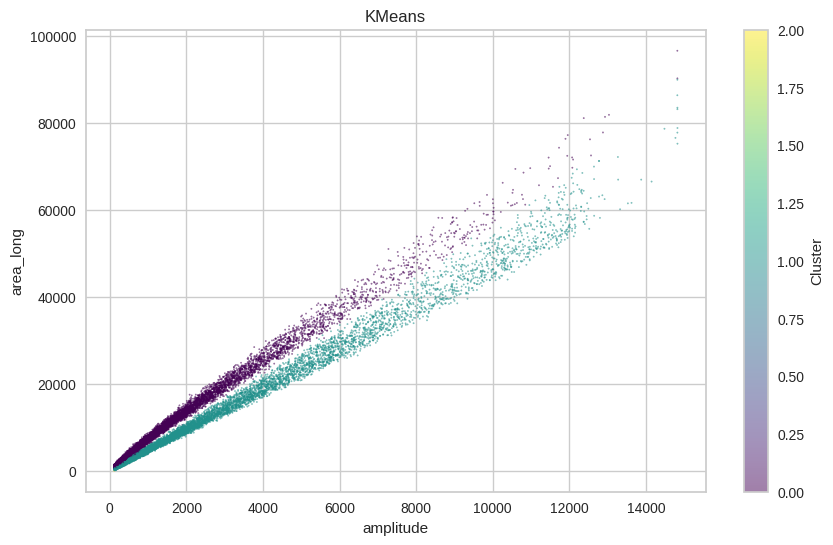

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(features['amplitude'], features['area_long'], c=raw_labels, cmap='viridis', s=1, alpha=0.5)
plt.xlabel('amplitude')
plt.ylabel('area_long')
plt.colorbar(label='Cluster')
plt.title('KMeans')
plt.show()

На полученном графике видно разделение веера сигналов на две основные ветви (кластеры 0 и 1), что указывает на разное соотношение площади к амплитуде у разных типов импульсов.

### Вывод

На основе проведенного анализа делаем вывод, что алгоритм KMeans в целом обеспечил высокое качество кластеризации по метрикам внутреннего разделения: коэффициент силуэта (0.607) и индекс Калински-Харабаша (25461.18) подтвердили устойчивость структуры и хорошую обособленность групп сигналов.

Однако полученное несбалансированное распределение объектов по кластерам (12 581, 10 897 и 1 объект) указывает на то, что модель практически не выделила случайный шум и аномалии, объединив их в один микрокластер из единственной точки. Чтобы попытаться более гибко описать плотность данных и улучшить идентификацию шумовых компонентов, на следующем этапе мы протестируем модель GaussianMixture.

## Обучение модели GaussianMixture

### Подбор гиперпараметров

Реализуем перебор различных типов ковариационных матриц (full, tied, diag, spherical). Опираясь на минимизацию информационных критериев AIC и BIC, определим оптимальную форму геометрии кластеров, которая позволит наиболее адекватно описать распределение плотности сигналов.

In [22]:
n_components = 3
covariance_types = ['full', 'tied', 'diag', 'spherical']

results = []
for cov_type in covariance_types:
    gmm_test = GaussianMixture(
        n_components=n_components,
        covariance_type=cov_type,
        random_state=42,
        n_init=5
    )
    gmm_test.fit(X)

    bic = gmm_test.bic(X)
    aic = gmm_test.aic(X)

    results.append({
        'covariance_type': cov_type,
        'BIC': bic,
        'AIC': aic
    })
results = pd.DataFrame(results)
print("Сравнение типов ковариационных матриц для 3-х кластеров:")
print(results.sort_values(by='BIC'))

Сравнение типов ковариационных матриц для 3-х кластеров:
  covariance_type            BIC            AIC
0            full -837590.272175 -839178.852926
1            tied -631088.555705 -631790.111671
2            diag -553694.398813 -554194.358237
3       spherical -196519.816756 -196802.051915


Минимальные значения критериев BIC и AIC достигаются при использовании типа ковариации full.

### Обучение

In [23]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42, n_init=5)
gmm_labels = gmm.fit_predict(X)

print("Модель успешно обучена. Распределение кластеров:")
print(pd.Series(gmm_labels).value_counts())

Модель успешно обучена. Распределение кластеров:
2    9378
0    7238
1    6863
Name: count, dtype: int64


### Оценка качества кластеризации

#### Метод силуэтов и индекс Калински-Харабаша

In [24]:
ch_gmm = calinski_harabasz_score(X, gmm_labels)
sil_gmm = silhouette_score(X, gmm_labels)
print(f"Calinski-Harabasz: {ch_gmm:.2f} | Silhouette: {sil_gmm:.3f}")

Calinski-Harabasz: 4636.02 | Silhouette: 0.174


Резкое снижение коэффициента силуэта до 0.174 и индекса Калински-Харабаша до 4636.02 указывает на ухудшение геометрической обособленности кластеров по сравнению с KMeans. Однако для окончательного вывода о качестве выделения шума мы сопоставим эти результаты с визуальным распределением плотности на графике рассеяния и структурой силуэтных профилей.

#### График рассеяния

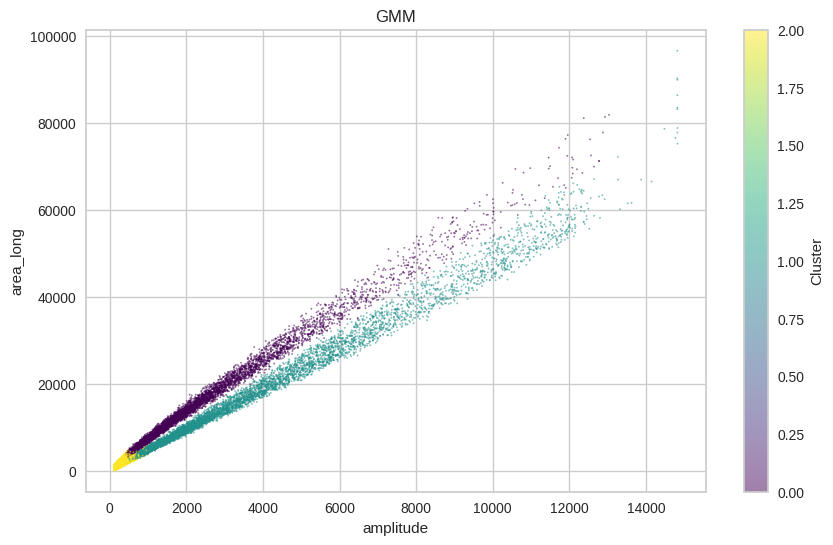

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(features['amplitude'], features['area_long'], c=gmm_labels, cmap='viridis', s=1, alpha=0.5)
plt.xlabel('amplitude')
plt.ylabel('area_long')
plt.colorbar(label='Cluster')
plt.title('GMM')
plt.show()

График рассеяния показывает, что модель выделила в отдельный класс (желтый цвет) низкоамплитудный шум у начала координат, сохранив разделение основных физических ветвей.

#### Анализ силуэтных профилей

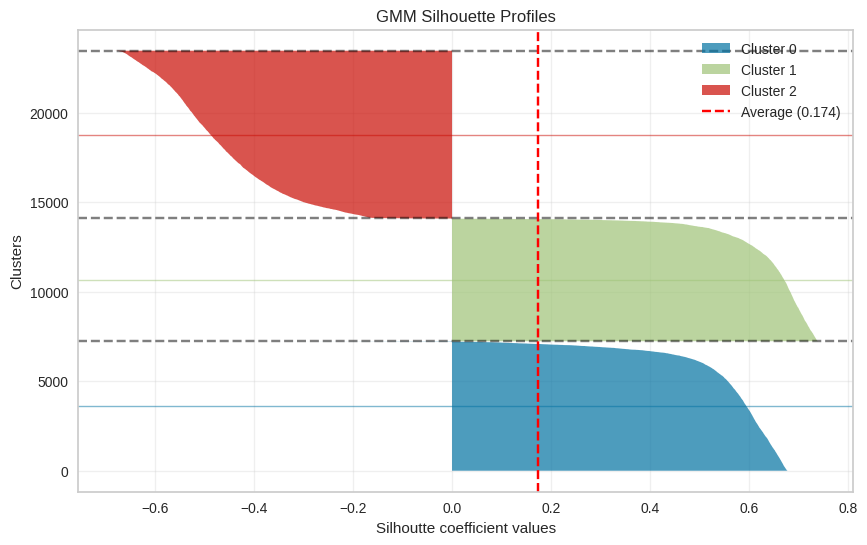

In [26]:
sil_avg = silhouette_score(X, gmm_labels)
sample_sil = silhouette_samples(X, gmm_labels)

y_lower, y_upper = 0, 0
plt.figure(figsize=(10, 6))

for i in range(3):
    cluster_sil = sample_sil[gmm_labels == i]
    cluster_sil_sorted = np.sort(cluster_sil)[::-1]

    size = len(cluster_sil_sorted)
    y_upper = y_lower + size

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_sorted,
                      alpha=0.7, label=f'Cluster {i}')

    plt.axhline(y=y_upper, color='black', linestyle='--', alpha=0.5)

    plt.axhline(y=y_lower + size/2, color=f'C{i}', linestyle='-', alpha=0.5, linewidth=1)

    y_lower = y_upper

plt.axvline(x=sil_avg, color='red', linestyle='--', label=f'Average ({sil_avg:.3f})')

plt.ylabel('Clusters')
plt.xlabel('Silhoutte coefficient values')
plt.title('GMM Silhouette Profiles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

В результате анализа силуэтных профилей можно сделать вывод о том, что геометрия разбиения неудовлетворительна. Кластеры 0 и 1 демонстрируют стабильные ядра со значениями до 0.7, что подтверждает выделение двух основных трендов. Однако кластер 2 полностью уходит в отрицательную зону (до -0.7). Это свидетельствует о критическом нарушении компактности: его объекты находятся ближе к соседним группам, чем к собственному центру. Данная размытая компонента утягивает общий средний силуэт модели к низкому значению 0.174, что указывает на необходимость более жесткой предварительной фильтрации шума.

### Вывод

На основе полученных результатов отдадим предпочтение алгоритму KMeans. Модель Gaussian Mixture демонстрирует значительно более худшее качество кластеризации: она критически размывает границы классов и уводит силуэтный профиль шумовой компоненты глубоко в отрицательную зону (до -0.7).

Однако, несмотря на высокую геометрическую обособленность основных групп у KMeans, этот алгоритм в исходном виде практически не выделяет фоновый шум. Чтобы компенсировать данный недостаток, мы будем выделять шум дополнительно - путем последующей изолированной кластеризации каждого из полученных основных кластеров.

# Обучение выбранной модели (K-Means)

## Обучение

Обучим модель K-Means с подобранными гиперпараметрами.

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=100)
labels = kmeans.fit_predict(X)

print("Модель успешно обучена. Распределение кластеров:")
print(pd.Series(labels).value_counts())

Модель успешно обучена. Распределение кластеров:
0    12581
1    10897
2        1
Name: count, dtype: int64


## Дополнительное выделение шумовой компоненты

Для изоляции фонового шума мы применим двухступенчатую фильтрацию, декомпозировав каждый из основных кластеров (кластеры 0 и 1) на подкластеры с помощью повторного запуска KMeans.

На этапе предварительного анализа мы выяснили, что полезные сигналы от зарегистрированных частиц характеризуются гораздо большей амплитудой, в то время как шумы и аппаратные сбои имеют аномально малую интенсивность. Опираясь на это физическое свойство, внутри каждой группы мы локализуем подкластеры с минимальной средней амплитудой, идентифицируем их как фоновые выбросы и принудительно переведем в класс 2. Это позволит эффективно очистить геометрию основных распределений.

In [28]:
neutron_mask = (labels == 1)
neutron_sub = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X[neutron_mask])
neutron_sorted = features.loc[neutron_mask, 'amplitude'].groupby(neutron_sub).mean().sort_values().index

labels[neutron_mask] = np.where(np.isin(neutron_sub, neutron_sorted[:1]), 2, 1)

gamma_mask = (labels == 0)
gamma_sub = KMeans(n_clusters=8, random_state=42, n_init=10).fit_predict(X[gamma_mask])
gamma_noise_idx = features.loc[gamma_mask, 'amplitude'].groupby(gamma_sub).mean().idxmin()

labels[gamma_mask] = np.where(gamma_sub == gamma_noise_idx, 2, 0)

print("Итоговое распределение по кластерам:")
print(pd.Series(labels).value_counts().sort_index())

Итоговое распределение по кластерам:
0    11465
1    10879
2     1135
Name: count, dtype: int64


## Оценка качества кластеризации

### Визуализация

Визуализируем полученное разбиение на двух диаграммах рассеяния для оценки качества проведенной фильтрации. Графики подтверждают корректность работы двухступенчатого алгоритма: основные физические ветви разделены без взаимного пересечения (кластеры 0 и 1), а низкоамплитудный шум и сопутствующие фоновые выбросы успешно изолированы в кластер 2. Использование подкластеризации позволило обойти ограничения стандартного метода KMeans и добиться точной локализации шума при сохранении геометрии ключевых распределений.

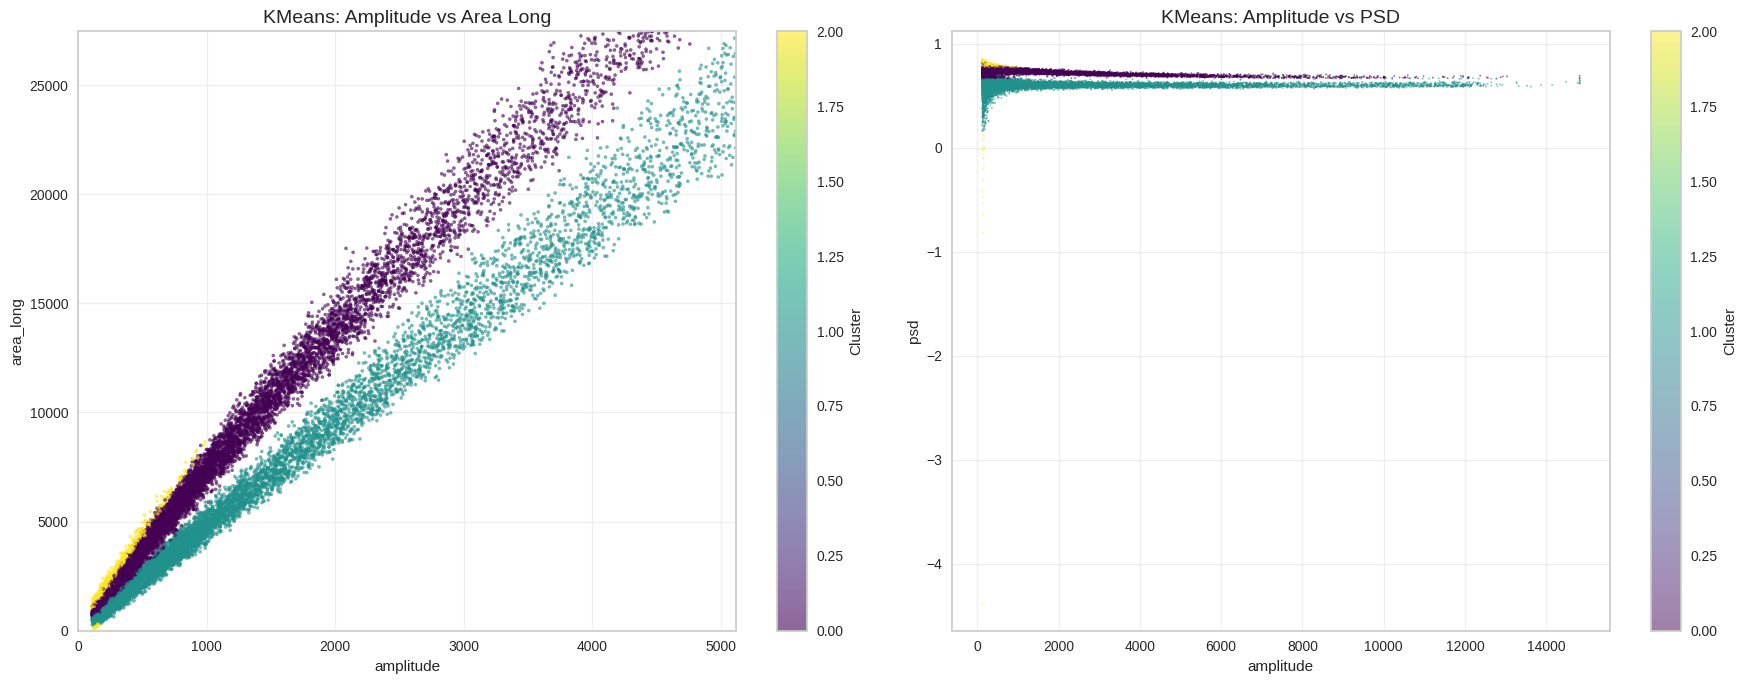

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
scatter1 = ax1.scatter(features['amplitude'], features['area_long'],
                       c=labels, cmap='viridis', s=5, alpha=0.6)

x_low, x_high = -1, features['amplitude'].quantile(0.9)
y_low, y_high = -1, features['area_long'].quantile(0.9)
ax1.set_xlim(x_low, x_high)
ax1.set_ylim(y_low, y_high)

ax1.set_xlabel('amplitude')
ax1.set_ylabel('area_long')
ax1.set_title('KMeans: Amplitude vs Area Long', fontsize=14)
ax1.grid(True, alpha=0.3)
fig.colorbar(scatter1, ax=ax1, label='Cluster')

scatter2 = ax2.scatter(features['amplitude'], features['psd'],
                       c=labels, cmap='viridis', s=1, alpha=0.5)

ax2.set_xlabel('amplitude')
ax2.set_ylabel('psd')
ax2.set_title('KMeans: Amplitude vs PSD', fontsize=14)
ax2.grid(True, alpha=0.3)
fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.show()

### Загрузка решения на Kaggle

На Kaggle получен результат 0.84032.

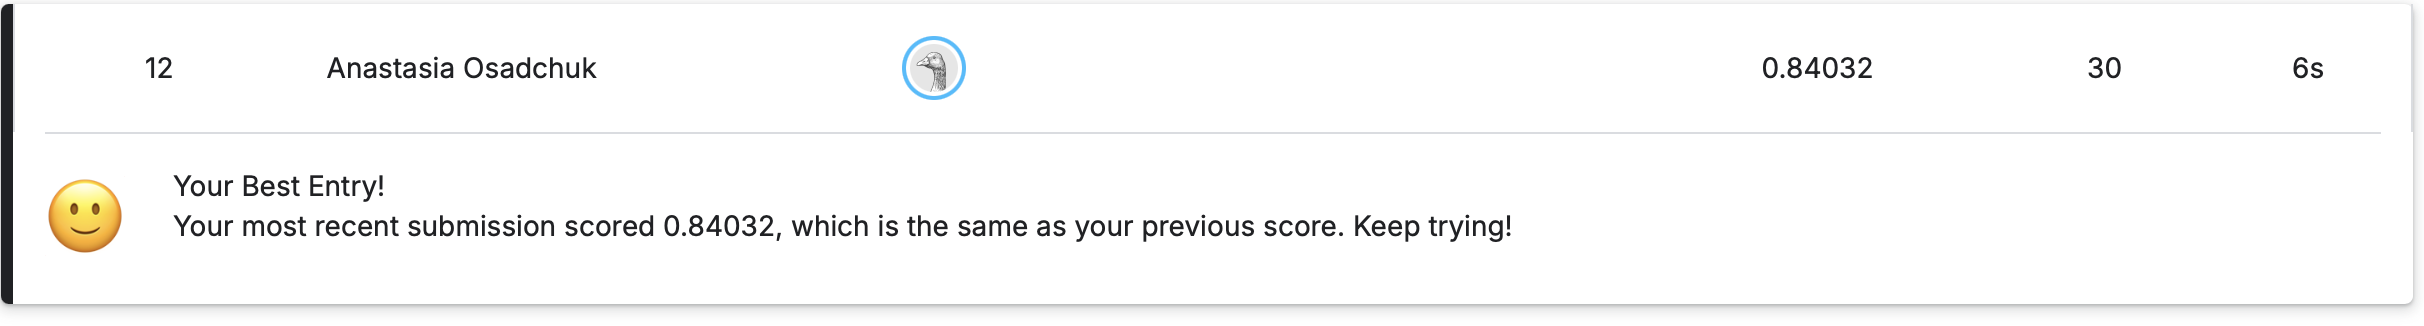

In [30]:
results = pd.DataFrame({
    'index': range(len(labels)),
    'cluster': labels
})
results.to_csv('result.csv', index=False)

Image('res.png')

# Заключение

В ходе работы была выполнена кластеризация сцинтилляционных сигналов на три группы: сигналы гамма-квантов, нейтронов и шумовые события.

Основными использованными признаками стали параметры формы импульса, в первую очередь PSD и доли заряда в хвосте. Применение KMeans с реализованной двухступенчатой фильтрацией шума позволило получить устойчивое разделение.
Финальный результат на Kaggle составил 0.84032.

Работа показала, что для эффективного Pulse Shape Discrimination (PSD) в органических сцинтилляторах информативность сосредоточена в динамике спада импульса, тогда как одномерные параметры (амплитуда и полный заряд) недостаточны для разделения из-за существенного перекрытия энергетических спектров частиц.